# Scryfall Card OCR Fine-Tuning

This notebook explores the `card_image_text_manifest.jsonl` dataset and fine-tunes a TrOCR-based OCR model with LoRA adapters for structured MTG card text extraction.

In [2]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

workspace_root = Path.cwd()
if workspace_root.name == "notebooks":
    workspace_root = workspace_root.parent
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from src.card_ocr import CardOCRFineTuner, CardOCRTrainingConfig, load_manifest_records, summarize_manifest
from src.card_ocr.augmentations import CardOCRAugmenter
from src.card_ocr.config import OCRAugmentationConfig

In [3]:
manifest_path = Path("../data/card_image_text_manifest.jsonl")
records = load_manifest_records(manifest_path, skip_missing_images=False)
summary = summarize_manifest(records)
summary

{'num_records': 8447, 'split_counts': {'train': 6717, 'val': 1680, 'test': 50}}

In [4]:
df = pd.DataFrame(records)
df[["card_name", "split", "image_path"]].head()

,card_name,split,image_path
0,Ascended Lawmage,train,C:\Documents\GitHub\scryfall-llm-sandbox\data\...
1,Kami of Transmutation,train,C:\Documents\GitHub\scryfall-llm-sandbox\data\...
2,Felidar Umbra,train,C:\Documents\GitHub\scryfall-llm-sandbox\data\...
3,Chainbreaker,train,C:\Documents\GitHub\scryfall-llm-sandbox\data\...
4,"Tymaret, the Murder King",train,C:\Documents\GitHub\scryfall-llm-sandbox\data\...


In [5]:
sample_record = next(record for record in records if Path(record["image_path"]).exists())
sample_image = Image.open(sample_record["image_path"]).convert("RGB")
sample_record["card_name"], sample_image.size

('Ascended Lawmage', (745, 1040))

In [5]:
config = CardOCRTrainingConfig(
    manifest_path=str(manifest_path),
    base_model_name="microsoft/trocr-base-printed",
    output_dir="../models/scryfall-card-ocr",
    image_height=576,
    image_width=800,
    interpolate_pos_encoding=True,
    max_target_length=512,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=8,
    learning_rate=2e-4,
)
config

CardOCRTrainingConfig(manifest_path='..\\data\\card_image_text_manifest.jsonl', base_model_name='microsoft/trocr-base-printed', output_dir='../models/scryfall-card-ocr', image_height=576, image_width=800, interpolate_pos_encoding=True, max_target_length=512, per_device_train_batch_size=1, per_device_eval_batch_size=1, gradient_accumulation_steps=8, num_train_epochs=8, learning_rate=0.0002, weight_decay=0.01, warmup_ratio=0.1, logging_steps=10, save_total_limit=2, generation_max_length=512, generation_num_beams=1, gradient_checkpointing=True, dataloader_num_workers=0, early_stopping_patience=3, report_to='none', seed=42, use_fp16=True, use_bf16=False, skip_missing_images=True, train_split_name='train', eval_split_name='val', test_split_name='test', augmentations=OCRAugmentationConfig(rotation_degrees=10.0, rotation_probability=0.7, blur_probability=0.3, blur_radius_min=0.2, blur_radius_max=1.4, dilation_probability=0.2, erosion_probability=0.2, downscale_probability=0.3, downscale_min_s

In [6]:
fine_tuner = CardOCRFineTuner(config)
len(fine_tuner.train_dataset), len(fine_tuner.eval_dataset), len(fine_tuner.test_dataset)

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

c:\Documents\GitHub\scryfall-llm-sandbox\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\nccru\.cache\huggingface\hub\models--microsoft--trocr-base-printed. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

trainable params: 3,932,160 || all params: 337,853,952 || trainable%: 1.1639


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


(6716, 1680, 50)

In [7]:
batch = fine_tuner.data_collator([fine_tuner.train_dataset[0]])
{key: value.shape if hasattr(value, "shape") else value for key, value in batch.items()}

{'pixel_values': torch.Size([1, 3, 576, 800]),
 'labels': torch.Size([1, 128]),
 'interpolate_pos_encoding': True}

In [8]:
fine_tuner.model.print_trainable_parameters()

trainable params: 3,932,160 || all params: 337,853,952 || trainable%: 1.1639


## Augmentation Preview

These cells pick a random card image and visualize each augmentation independently, followed by one example of the full randomized augmentation pipeline.

In [6]:
preview_record = random.choice([record for record in records if Path(record["image_path"]).exists()])
preview_image = Image.open(preview_record["image_path"]).convert("RGB")
preview_record["card_name"], preview_image.size

('Prime Speaker Zegana', (745, 1040))

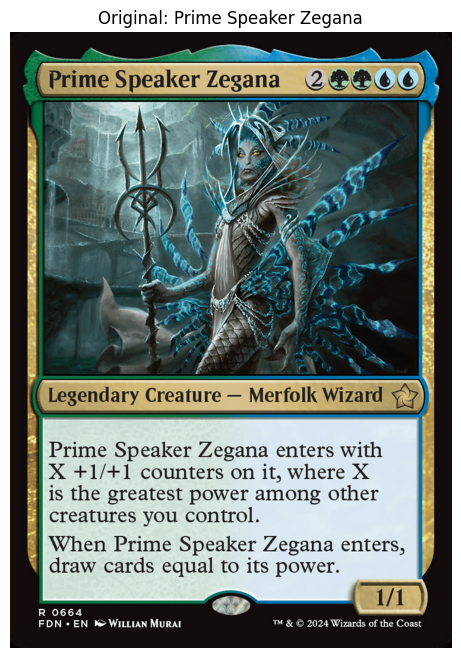

In [7]:
plt.figure(figsize=(6, 8))
plt.imshow(preview_image)
plt.title(f"Original: {preview_record['card_name']}")
plt.axis("off");

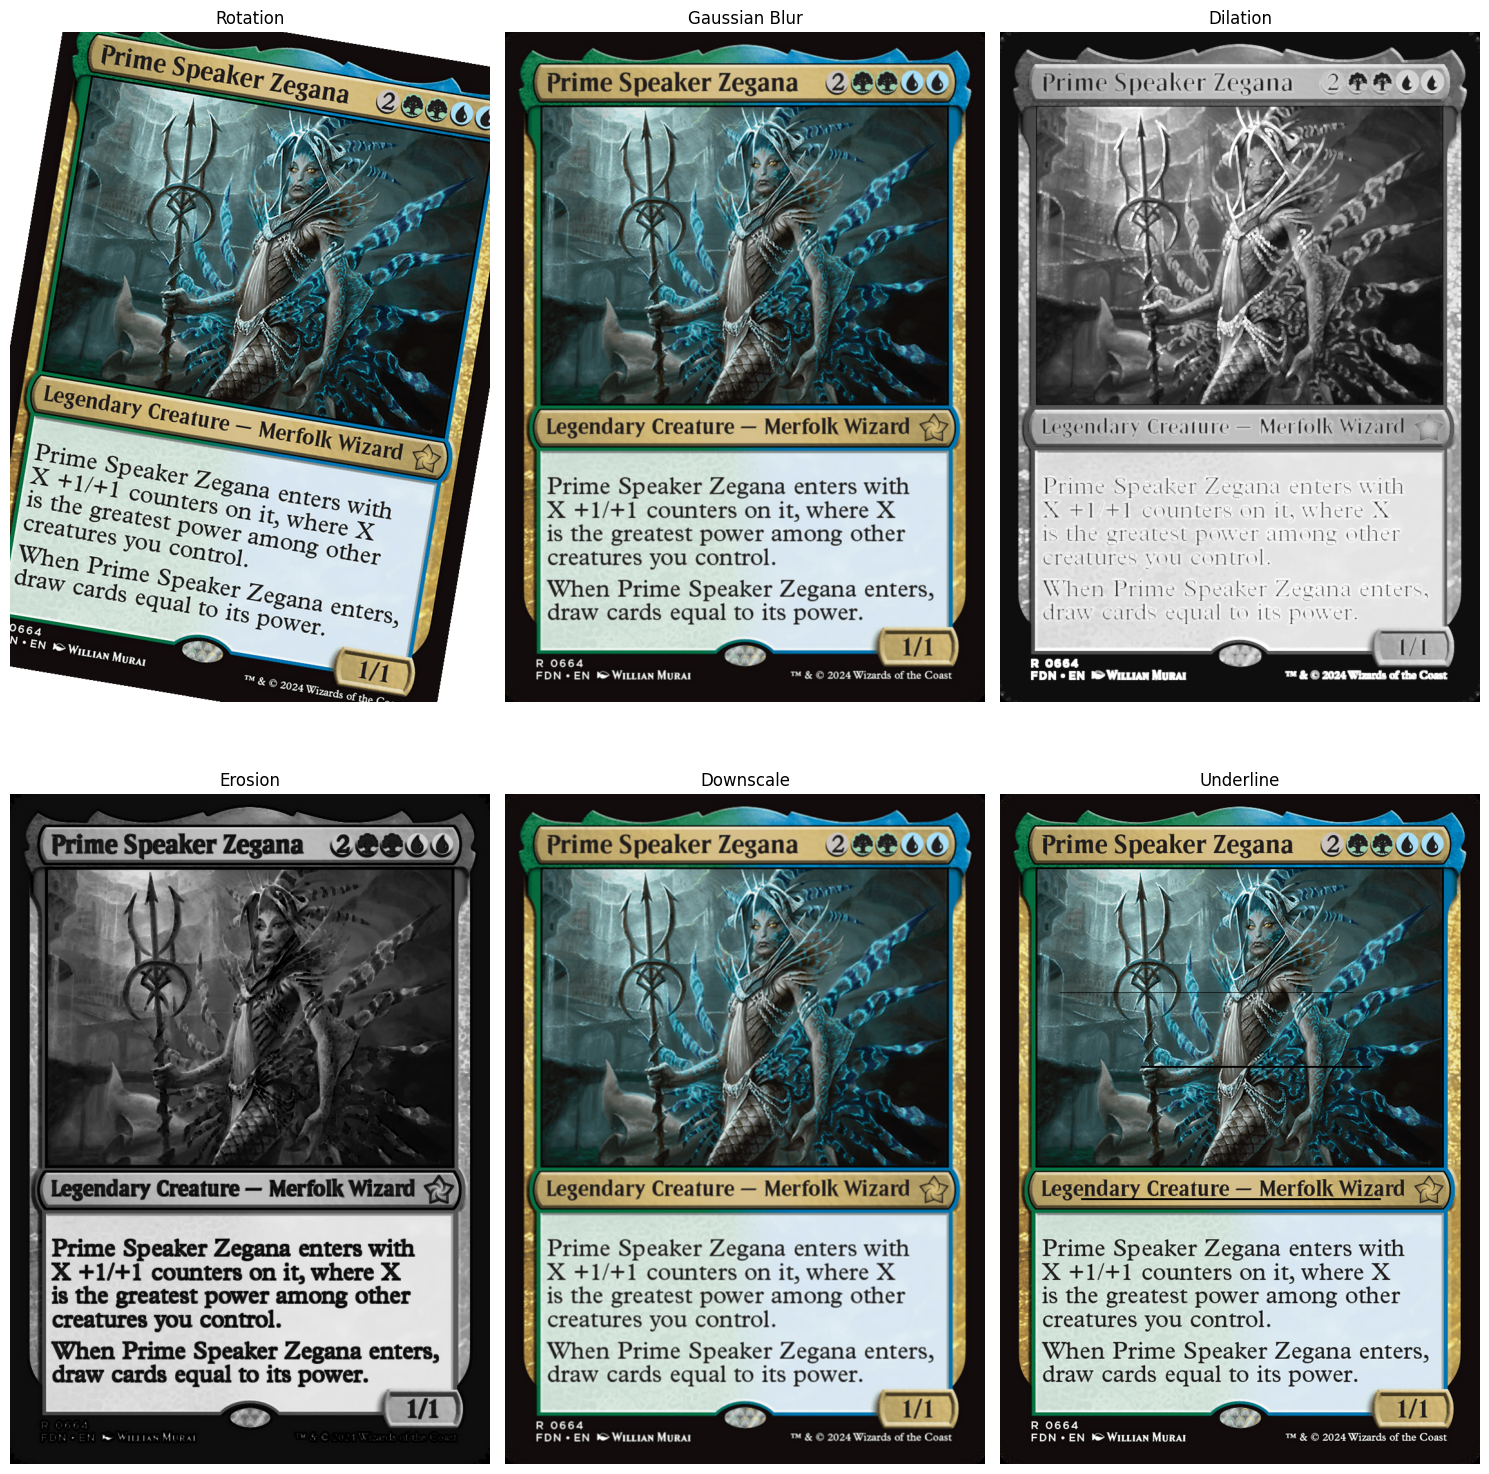

In [8]:
base_aug = OCRAugmentationConfig(
    rotation_probability=0.0,
    blur_probability=0.0,
    dilation_probability=0.0,
    erosion_probability=0.0,
    downscale_probability=0.0,
    underline_probability=0.0,
)

augmentation_previews = {
    "rotation": CardOCRAugmenter(OCRAugmentationConfig(**(base_aug.__dict__ | {"rotation_probability": 1.0}))),
    "gaussian blur": CardOCRAugmenter(OCRAugmentationConfig(**(base_aug.__dict__ | {"blur_probability": 1.0}))),
    "dilation": CardOCRAugmenter(OCRAugmentationConfig(**(base_aug.__dict__ | {"dilation_probability": 1.0}))),
    "erosion": CardOCRAugmenter(OCRAugmentationConfig(**(base_aug.__dict__ | {"erosion_probability": 1.0}))),
    "downscale": CardOCRAugmenter(OCRAugmentationConfig(**(base_aug.__dict__ | {"downscale_probability": 1.0}))),
    "underline": CardOCRAugmenter(OCRAugmentationConfig(**(base_aug.__dict__ | {"underline_probability": 1.0}))),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 16))
for axis, (name, augmenter) in zip(axes.flatten(), augmentation_previews.items(), strict=False):
    axis.imshow(augmenter(preview_image.copy(), rng=random.Random(42)))
    axis.set_title(name.title())
    axis.axis("off")
plt.tight_layout()

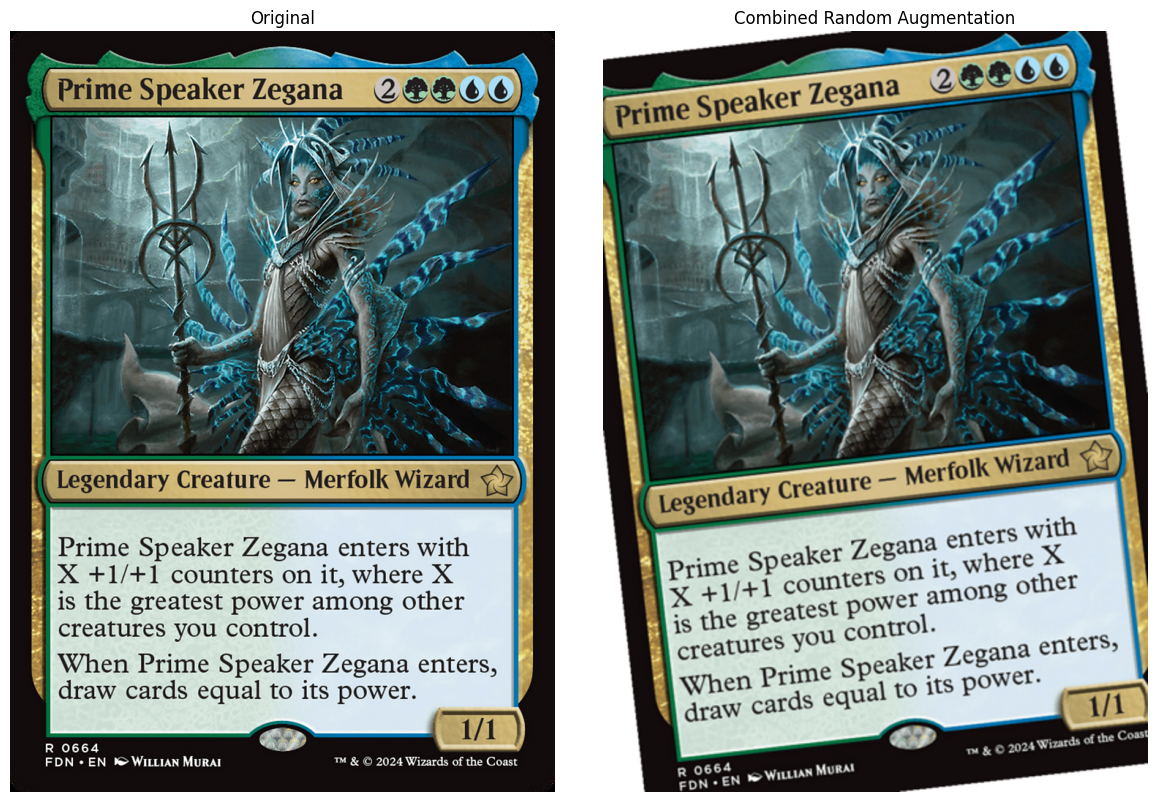

In [22]:
combined_augmenter = CardOCRAugmenter(OCRAugmentationConfig())
combined_preview = combined_augmenter(preview_image.copy(), rng=random.Random())

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].imshow(preview_image)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(combined_preview)
axes[1].set_title("Combined Random Augmentation")
axes[1].axis("off")
plt.tight_layout()

In [ ]:
# Uncomment when you're ready to train.
# train_result = fine_tuner.train()
# train_result

In [ ]:
# Optional evaluation after training.
# fine_tuner.evaluate()

In [ ]:
# Example inference after training.
# prediction = fine_tuner.generate_from_image(sample_image.resize((config.image_width, config.image_height)))
# print(prediction)